In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"titanjd","key":"13a24d9a0251f2dbe716b6e90c2431e4"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [22]:
#!/bin/bash
!kaggle datasets download shraddha4ever20/multivariate-5d-dataset-for-pca-and-ml

Dataset URL: https://www.kaggle.com/datasets/shraddha4ever20/multivariate-5d-dataset-for-pca-and-ml
License(s): Attribution 4.0 International (CC BY 4.0)
100% 228k/228k [00:00<00:00, 772kB/s]



In [23]:
import zipfile
import os

# Specify the name of the downloaded zip file (e.g., 'titanic.zip')
zip_file_name = 'multivariate-5d-dataset-for-pca-and-ml.zip'

# Create a directory for the extracted files
destination_dir = '/content/dataset_files'
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

# (Optional) Remove the zip file after extraction
os.remove(zip_file_name)

# List the extracted files
print(f"Extracted files: {os.listdir(destination_dir)}")

Extracted files: ['PCA_5D_dataset.csv']


In [24]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/dataset_files/PCA_5D_dataset.csv'
df_pca = pd.read_csv(file_path)

# Display the first few rows and info to identify numeric columns
display(df_pca.head())
print(df_pca.info())

,feature1,feature2,feature3,feature4,feature5,target
0,-1.957269,-0.362373,-0.073370,1.014170,0.888492,1
1,-1.933645,0.637649,0.020616,0.514563,-0.384752,1
2,1.235969,0.975816,1.613172,3.426265,0.746320,0
3,-2.070954,0.672064,1.088641,-1.175259,-1.449853,1
4,-0.037408,0.578274,-1.125627,0.520184,-0.357349,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  5000 non-null   float64
 1   feature2  5000 non-null   float64
 2   feature3  5000 non-null   float64
 3   feature4  5000 non-null   float64
 4   feature5  5000 non-null   float64
 5   target    5000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 234.5 KB
None


In [27]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for PCA
numeric_df = df_pca.select_dtypes(include=[np.number])

# Handle missing values if any
numeric_df = numeric_df.fillna(numeric_df.mean())

# Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(numeric_df)

# Perform PCA (reducing to 3 components as requested)
pca = PCA(n_components=3)
principal_components = pca.fit_transform(x_scaled)

# Create a DataFrame with the three principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
# Add target if available for coloring
if 'target' in df_pca.columns:
    pca_df['target'] = df_pca['target']

# Variance explained
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total explained variance (3 PCs): {sum(pca.explained_variance_ratio_):.2%}')

display(pca_df.head())

Explained variance ratio: [0.4136642  0.13733514 0.13510554]
Total explained variance (3 PCs): 68.61%


,PC1,PC2,PC3,target
0,1.507199,0.828346,-1.596148,1
1,1.738256,0.708815,-0.372711,1
2,-2.410032,-1.235582,-0.792248,0
3,2.329229,0.828416,0.335677,1
4,1.518629,-0.145667,0.538244,1


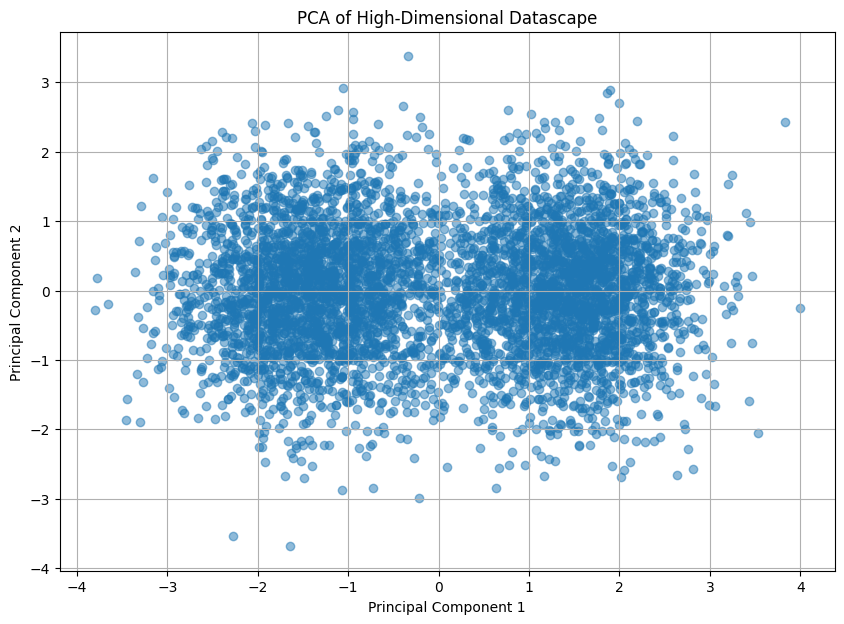

In [26]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of High-Dimensional Datascape')
plt.grid(True)
plt.show()

In [21]:
!rm -rf dataset_files/

In [28]:
import plotly.express as px

# Create a 3D scatter plot using Plotly
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='target' if 'target' in pca_df.columns else None,
    title='3D PCA of Multivariate 5D Dataset',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2', 'PC3': 'Principal Component 3'},
    opacity=0.7
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()